In [26]:
import pandas as pd


In [27]:
df=pd.read_csv("Salary_Data.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [28]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [30]:
import matplotlib.pyplot as plt

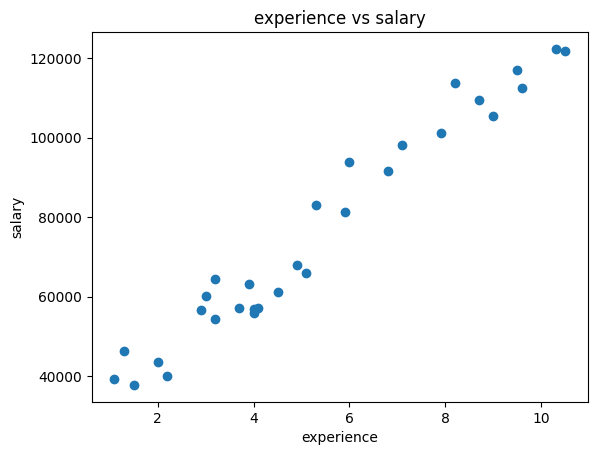

In [31]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.xlabel("experience")
plt.ylabel("salary")
plt.title("experience vs salary")
plt.show()

In [32]:
X = df[["YearsExperience"]]   # double brackets → 2D
y = df["Salary"]

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
print("Slope (w):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (w): 9423.815323030976
Intercept (b): 25321.583011776813


In [37]:
X_test


,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [38]:
y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [39]:
y_pred = model.predict(X_test)

In [40]:
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

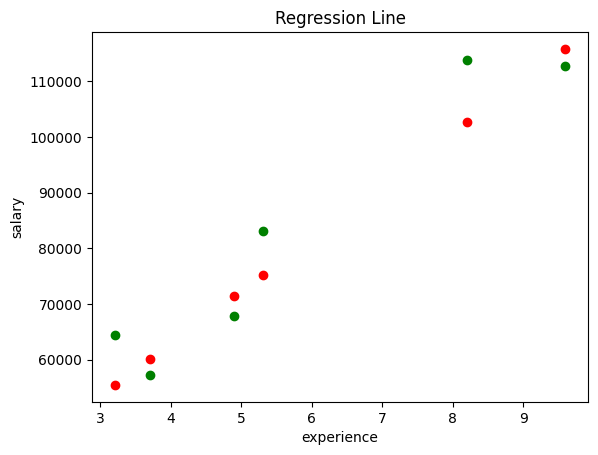

In [41]:
plt.scatter(X_test, y_test, color="green")
plt.scatter(X_test, y_pred, color="red")
plt.xlabel("experience")
plt.ylabel("salary")
plt.title("Regression Line")
plt.show()

In [42]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse=mse**0.5
print("rmse :",rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MSE: 49830096.85590839
rmse : 7059.04362190151
R2 Score: 0.9024461774180497
